## Aufgabe 4 - Kantendetektion ##

Aufgabe 1: Lesen Sie das Kapitel 7 (Kanten und Konturen) aus dem Buch ”Digitale Bildverarbeitung”. <br>

Aufgabe 2: Beantworten Sie folgende Fragen: <br>

a) Was ist eine Kante und wie ist sie im Bild, in dessen Ableitung und dessen zweiten
Ableitung erkennbar? <br>
A: Eine Kante ist ein Bildbereich, in dem sich die Helligkeit stark verändert. <br>
Im Originalbild erkennt man sie als Übergang zwischen hellen und dunklen Bereichen. <br>
In der ersten Ableitung erscheint sie als Extremwert (Minimum oder Maximum, wie stark Änderung),<br>
in der zweiten Ableitung oft als Nulldurchgang(wo 2abl = 0).(Wie verändert sich die erste Ableitung?)<br>

b) Was sind die partiellen Ableitungen eines Bildes? Was sagen sie aus? <br>
A: Partielle Ableitungen beschreiben die Helligkeitsänderung entlang der Achsen x und y (horizontal ∂I/∂x und vertikal ∂I/∂y). <br>
Sie geben an, wie stark und in welche Richtung sich die Helligkeit des Bildes verändert<br>

c) Was ist der Gradientenvektor (kurz: Gradient) eines Bildes? Was kann aus
diesem abgelesen werden? <br>
A: Der Gradient ∇I ist ein Vektor bestehend aus den beiden partiellen Ableitungen.<br>
Er zeigt die Richtung des stärksten Helligkeitsanstiegs und seine Länge gibt die Stärke dieses Anstiegs an<br>
(Zeigt dahin, wo Helligkeit am stärksten zunimmt.) <br>

d) Wie kann die Kantenstärke berechnet werden? <br>
A: Die Kantenstärke wird als Betrag des Gradienten berechnet: <br>
E(u,v)=wurzel(Dx(u,v)^2+Dy(u,v)) <br>
Dazu werden die Ableitungen in x- und y-Richtung quadratisch addiert und die Wurzel gezogen.<br>

e) Wie kann die lokale Kantenrichtung berechnet werden? <br>
A: Die lokale Kantenrichtung ergibt sich aus dem Winkel: <br>
ϕ(u,v)=atan2(Dy​,Dx​) <br> (berechnet den Winkel)
Sie gibt an, in welcher Richtung die Kante verläuft. Bei der Berechnung sollte die Funktion atan2 verwendet werden, um den Winkelbereich korrekt abzudecken.

Aufgabe 3: Implementieren Sie den Sobel-Operator

In [34]:
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import time

In [35]:
#Aufgabe 3 RGB -> Graustufen
def rgb_2_gray(img, mode='lut'):
    if mode == 'lut':
        return np.round(
            img[:, :, 0] * 0.2126 +
            img[:, :, 1] * 0.7152 +
            img[:, :, 2] * 0.0722
        ).astype("float64")
    else:
        return np.round(
            img[:, :, 0] * 0.299 +
            img[:, :, 1] * 0.587 +
            img[:, :, 2] * 0.114
        ).astype("float64")


In [36]:
img1 = io.imread("dot02.png") # dot02.png fhorn.png
gray = rgb_2_gray(img1)

In [37]:
# Horizontale 1D-Faltung <--->
def conv_horizontal(img, kernel):
    h, w = img.shape
    r = len(kernel) // 2
    padded = np.pad(img, ((0, 0), (r, r)), mode='edge') #Links und rechts wird Rand erweitert.

    result = np.zeros((h, w))

    for i in range(h):
        for j in range(w):
            region = padded[i, j:j+len(kernel)] #Es werden immer 3 Pixel (fenster) genommen und mit Kernel multipliziert.
            result[i, j] = np.sum(region * kernel)

    return result

In [38]:
# Vertikale 1D-Faltung (Gleiches Prinzip, aber spaltenweise.)
def conv_vertical(img, kernel):
    h, w = img.shape
    r = len(kernel) // 2
    padded = np.pad(img, ((r, r), (0, 0)), mode='edge')

    result = np.zeros((h, w))

    for i in range(h):
        for j in range(w):
            region = padded[i:i+len(kernel), j] #Gleiches Prinzip, aber nach oben/unten:
            result[i, j] = np.sum(region * kernel)

    return result

In [39]:
# Sobel X (erste Ableitung horizontal = vertikale Kanten)
def sobel_x(img):
    smooth = np.array([1, 2, 1]) #1+2+1=4
    diff   = np.array([-1, 0, 1]) #-1+0+1 = 2

    #Erst Differenz horizontal, dann glätten vertikal.
    temp = conv_horizontal(img, diff) # Wie stark ändert sich das Bild von links nach rechts?
    result = conv_vertical(temp, smooth) #vertikal glätten

    return result / 8.0 #normierungsfaktor: 4*2=8


# Sobel Y (erste vertikale Ableitung = horizontale Kanten)
def sobel_y(img):
    smooth = np.array([1, 2, 1]) 
    diff   = np.array([-1, 0, 1])

    #Erst oben/unten ableiten, dann glätten.
    temp = conv_vertical(img, diff) # Wie stark ändert sich das Bild von oben nach unten?
    result = conv_horizontal(temp, smooth) #hier wird getauscht, horizointal glätten

    return result / 8.0

In [40]:
def sobel_magnitude(img): #Gradientenbetrag, kombiniert ergebnisse
    gx = sobel_x(img) #horizontale Änderung <->
    gy = sobel_y(img) #vertikale Änderung

    return np.sqrt(gx**2 + gy**2) #Länge des Vektors.

In [41]:
#Laufzeit messen (Berechnung von Sobel X und Sobel Y)
start = time.time()
grad_x = sobel_x(gray)
end = time.time()
print("Dauer X:", (end - start) * 1000, "ms") #(1sek = 1000ms)

start = time.time()
grad_y = sobel_y(gray)
end = time.time()
print("Dauer Y:", (end - start) * 1000, "ms")

grad_mag = sobel_magnitude(gray)

Dauer X: 405.59911727905273 ms
Dauer Y: 450.72031021118164 ms


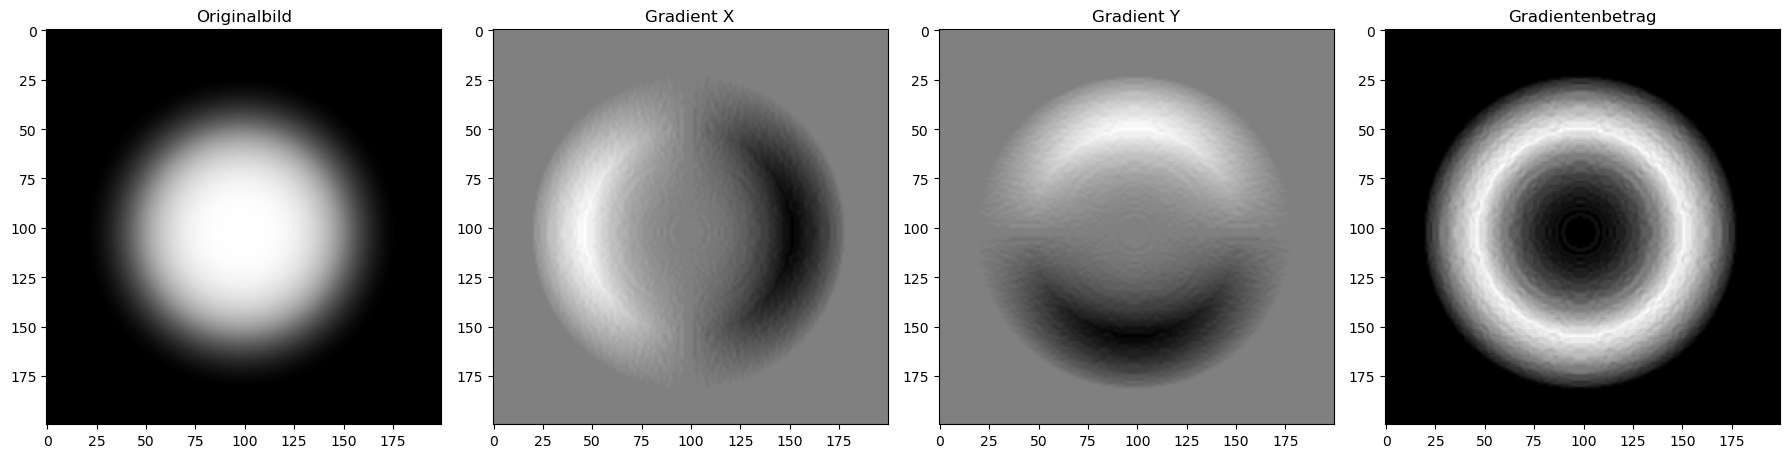

In [42]:
plt.figure(figsize=(18, 5))

plt.subplot(1, 4, 1)
plt.title("Originalbild")
plt.imshow(gray, cmap='gray')

plt.subplot(1, 4, 2)
plt.title("Gradient X")
plt.imshow(grad_x, cmap='gray')

plt.subplot(1, 4, 3)
plt.title("Gradient Y")
plt.imshow(grad_y, cmap='gray')

plt.subplot(1, 4, 4)
plt.title("Gradientenbetrag")
plt.imshow(grad_mag, cmap='gray')

plt.tight_layout()
plt.show()

Aufgabe 4: Beantworten Sie folgende Fragen: <br>

a) Was sind die Nachteile des Sobel-Operators? <br>
A: 
* Rauschempfindlich → reagiert stark auf Bildrauschen
* Unpräzise Kantenlokalisierung → (Kanten werden oft mehrere Pixel breit dargestellt statt als dünne Linie.)
* Richtungsabhängig → Sobel erkennt bevorzugt horizontale und vertikale Kanten, diagonale Kanten sind weniger exakt. <br>

b) Welche Alternativen gibt es zur Kantendetektion <br>
A: 
* Prewitt-Operator
    → ähnlich wie Sobel, einfacher aber weniger robust
* Roberts-Operator
    → sehr schnell, aber noch rauschanfälliger
* Canny-Edge-Detector
    → beste Qualität, besteht aus mehreren Schritten:
    * Glättung
    * Gradienten
    * Non-Maximum Suppression
    * Hysterese
* Laplace / Laplacian of Gaussian (LoG)
    → erkennt Kanten über zweite Ableitung